In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import shap

# 1. Simulação de Dados (Target: Propensão de Compra)
np.random.seed(42)
data = pd.DataFrame({
    'idade': np.random.randint(18, 70, 1000),
    'renda': np.random.normal(5000, 1500, 1000),
    'categoria_favorita': np.random.choice(['eletronicos', 'roupas', 'livros'], 1000),
    'dias_desde_ultimo_acesso': np.random.randint(1, 30, 1000),
    'comprou': np.random.choice([0, 1], 1000, p=[0.8, 0.2]) # Classes desbalanceadas
})

# Inserindo nulos aleatórios para demonstrar tratamento
data.loc[10:50, 'renda'] = np.nan

X = data.drop('comprou', axis=1)
y = data['comprou']

# 2. Train/Test Split (Separação rigorosa ANTES de qualquer transformação)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Construção da Pipeline de Preprocessamento
numeric_features = ['idade', 'renda', 'dias_desde_ultimo_acesso']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputação robusta a outliers
    ('scaler', StandardScaler())                   # Previne peso desproporcional
])

categorical_features = ['categoria_favorita']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Lida com novas categorias em produção
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Pipeline Completa (Preprocessamento + Modelo)
# Uso de class_weight='balanced' para mitigar o desbalanceamento
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))
])

# 5. Treinamento e Cross-Validation
# Usando validação cruzada para garantir estabilidade (sem leakage, pois a pipeline roda a cada fold)
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print(f"ROC-AUC em Cross-Validation (Média): {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Treino final no conjunto inteiro de treino
model_pipeline.fit(X_train, y_train)

# 6. Avaliação Out-of-Sample (Teste)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("\nRelatório de Classificação (Test Set):")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC (Test Set): {roc_auc_score(y_test, y_proba):.3f}")

# 7. Interpretabilidade com SHAP (Opcional, focado no modelo dentro da pipeline)
# Extraímos os dados transformados para explicar o modelo
X_test_transformed = model_pipeline.named_steps['preprocessor'].transform(X_test)
rf_model = model_pipeline.named_steps['classifier']

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)


ROC-AUC em Cross-Validation (Média): 0.526 (+/- 0.072)

Relatório de Classificação (Test Set):
              precision    recall  f1-score   support

           0       0.82      0.68      0.74       163
           1       0.20      0.35      0.25        37

    accuracy                           0.62       200
   macro avg       0.51      0.52      0.50       200
weighted avg       0.71      0.62      0.65       200

ROC-AUC (Test Set): 0.490


In [5]:
feature_names = numeric_features + list(model_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))

C:\Users\GustavoHenriqueSilva\AppData\Local\Temp\ipykernel_2632\3964661179.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


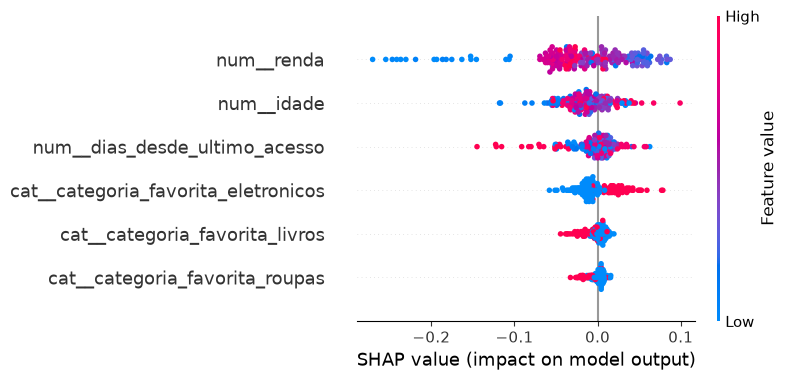

In [9]:
import numpy as np

# 1. Pega os nomes das colunas
nomes_das_colunas = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Descobre o formato que o SHAP devolveu e extrai a Classe 1 corretamente
if isinstance(shap_values, list):
    # Se for lista (SHAP antigo)
    valores_shap_classe_1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # Se for array 3D (SHAP novo): Pega todas as linhas, todas as colunas, índice 1 (Classe 1)
    valores_shap_classe_1 = shap_values[:, :, 1]
else:
    # Casos raros onde ele já devolve 2D
    valores_shap_classe_1 = shap_values

# 3. Garante que os dados transformados não sejam uma "matriz esparsa" 
# (o SHAP precisa de matrizes densas tradicionais para plotar)
if hasattr(X_test_transformed, "toarray"):
    dados_densos = X_test_transformed.toarray()
else:
    dados_densos = X_test_transformed

# 4. Plota o gráfico com tudo ajustado!
shap.summary_plot(
    valores_shap_classe_1, 
    dados_densos, 
    feature_names=nomes_das_colunas
)